#Final Assignment

## DTSC-680: Applied Machine Learning

## Name: Naima Rais

##Overview
The goal of this notebook is to create a machine leaning model to predict whether a mushroom is poisonous or edible based on its features. The dataset contains 8124 instances and 23 attributes.

In [ ]:
# common imports
import numpy as np
import pandas as pd

In [ ]:
# Define the column headers based on .names file

column_header = ["class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat" ]

In [ ]:
# reading .csv
df = pd.read_csv('agaricus-lepiota.csv', header=None, names=column_header)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

There are no null values in the data.

In [ ]:
# check 'class' imbalance
df['class'].value_counts()

,count
class,
e,4208
p,3916


The data is balanced.

In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Spilliting the data using train_test_split to train our model using training data

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (6499, 22)
Testing set size: (1625, 22)


Label encoding the 'class' feature so that it can be used to train the model.

In [ ]:
# label encoding of the target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  #only fitting the training data
y_test_encoded = le.transform(y_test)


In [ ]:
# one Hot encoding of the featues
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore")
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

In [ ]:
print(f"Encoded training features shape: {X_train_encoded.shape}")
print(f"Encoded testing features shape: {X_test_encoded.shape}")

Encoded training features shape: (6499, 116)
Encoded testing features shape: (1625, 116)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# instantiate an object of the Sequential class
model = Sequential()

# add input and hidden layers
model.add(Dense(128, input_dim=116, activation='relu'))
model.add(Dense(32, activation='relu'))

# add output layer with sigmoid activation function
model.add(Dense(1, activation='sigmoid'))

# use binary_crossentropy loss and accuracy metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# use time magic commamd to time the model training
%%time

#Train the network using the part of the dataset split off for training
hist = model.fit(X_train_encoded, y_train_encoded, epochs=10, batch_size=30, validation_data=(X_test_encoded, y_test_encoded))

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9228 - loss: 0.2495 - val_accuracy: 0.9975 - val_loss: 0.0201
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9998 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 8.1190e-04
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 6.2814e-04 - val_accuracy: 1.0000 - val_loss: 5.3973e-04
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 4.7752e-04 - val_accuracy: 1.0000 - val_loss: 3.8585e-04
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 2.910

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


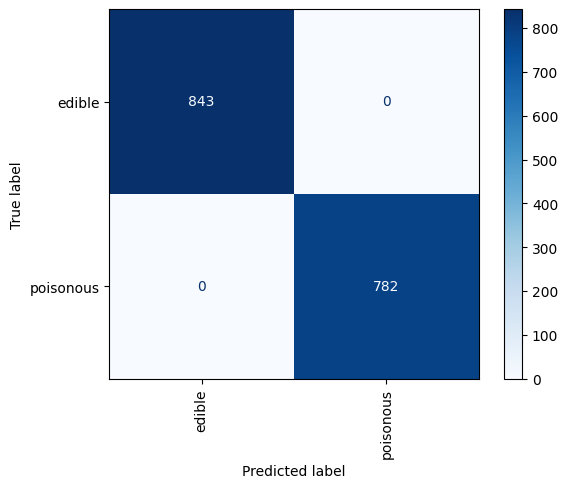

In [ ]:
# create confusion matrix to analyze the result, import seaborn
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay as cmd

sns.reset_orig()
y_pred = model.predict(X_test_encoded)
y_pred = np.round(y_pred).flatten().astype(int)
labels = ['edible', 'poisonous']
cmd.from_predictions(y_test_encoded, y_pred, display_labels=labels, cmap='Blues', xticks_rotation='vertical')

In [ ]:
# reduce dimensions using PCA and retain 95% variance
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_encoded.toarray())
X_test_pca = pca.transform(X_test_encoded.toarray())

In [ ]:
X_train_pca.shape

(6499, 40)

In [ ]:
X_train_encoded.shape

(6499, 116)

In [ ]:
# train a new neural network using PCA-transformed data
model_pca = Sequential()
model_pca.add(Dense(128, input_dim=40, activation='relu'))
model_pca.add(Dense(32, activation='relu'))
model_pca.add(Dense(1, activation='sigmoid'))
model_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_pca.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# using time again for pca model
%%time
pca_hist = model_pca.fit(X_train_pca, y_train_encoded, epochs=10, batch_size=30, validation_data=(X_test_pca, y_test_encoded))

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9061 - loss: 0.3627 - val_accuracy: 0.9895 - val_loss: 0.0551
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9937 - loss: 0.0393 - val_accuracy: 0.9988 - val_loss: 0.0191
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.

It took 7.82 seconds to run the pca model while the regular model took 10.4 seconds. This is proof that dimentinality reduction reduced the time.

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


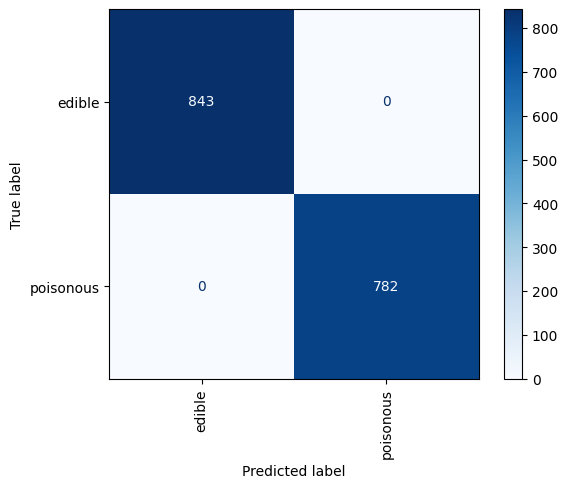

In [ ]:
# Analyze result using confusion matrix
y_pred_pca = model_pca.predict(X_test_pca)
y_pred_pca = np.round(y_pred_pca).flatten().astype(int)
cm_pca = cmd.from_predictions(y_test_encoded, y_pred_pca, display_labels=labels, cmap='Blues', xticks_rotation='vertical')

The confusion matrix shows the accuracy of model. We have 843 true positives and 782 true negatives. Our model is working 100% accurate with no flase positives or false negatives.

In [ ]:
model_pca.save('model_pca.h5')   # saving the model

Some of the concepts that we were able to get from this notebook.


a) How many features does the data have after the One-Hot Encoding? How does this compare to the number of features that the data had before the encoding?

Ans) There are 116 features after One-Hot Encoding. We had 22 before minus the 'class' attribute. One-Hot Encoding changed the data into binary hence more number of columns for each response.

b) What should the units parameter of the output layer in the network be and why?

Ans) The units parameter of the output layer should be 1 as it is a binary classification.

c)How many connections does your neural network contain?

Ans) The number of connections is calculated by (input_dim * units) + units. In this case we have three layers. We will sum the connections of all three layers to get the total connection.

first layer = (128 x 116) + 128 = 14976

second layer = (32 x 128) +32 = 4128

third layer = (1 x 32) + 1 = 33

Total = 14976 + 4128 + 33 = 19137 connections in the first neural network

d) How many features does the training data contain after dimensionality reduction? How does this compare with the encoded data?

Ans) The training data contains 40 features from dimenionality reduction while encoded data had 117. Dimentionality reduction worked really well and has reduced the dimention significantly.

e) Why does the input_dim parameter of the first layer need to change from the previous neural network?

Ans) the input_dim parameter needed to be changed because we used dimentionality reduction technique and it had significantly reduced the number of features.

f) Compare the training time of the original neural network with the training time of the PCA neural network. Are the results what you expected?

Ans) The training time of the original neural network was 10.4 seconds while the PCA neural network took 7.82 seconds which is less than the original one. We expected the same and the results were according to the expectations.